In [1]:
# Cell 1: Import library dan load dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset dari folder dataset
df = pd.read_csv('dataset/Train_data.csv')

# Menampilkan 5 baris pertama untuk memastikan data berhasil dimuat
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


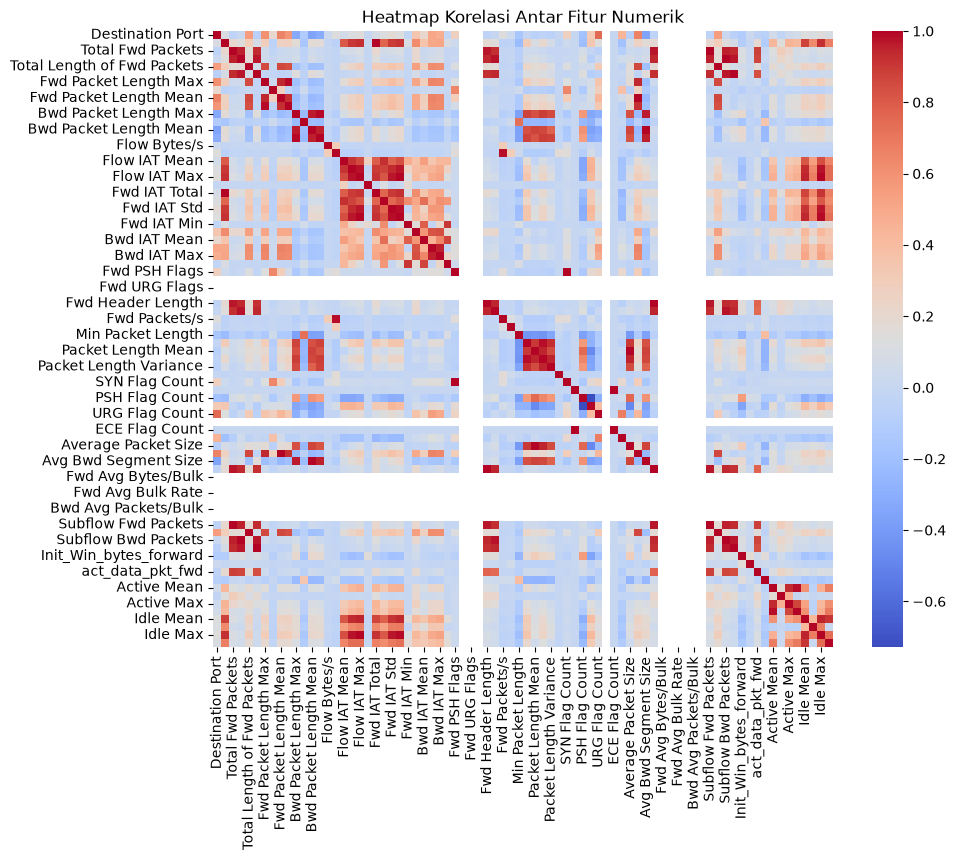

In [2]:
# Cell 2: Membuat Heatmap Korelasi
plt.figure(figsize=(10, 8))

# Memilih hanya kolom yang berisi angka (numerik) untuk dihitung korelasinya
numeric_df = df.select_dtypes(include=['number'])

# Membuat heatmap menggunakan seaborn
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm')

plt.title('Heatmap Korelasi Antar Fitur Numerik')
plt.show()

Nama kolom target otomatis terdeteksi: ' Label'


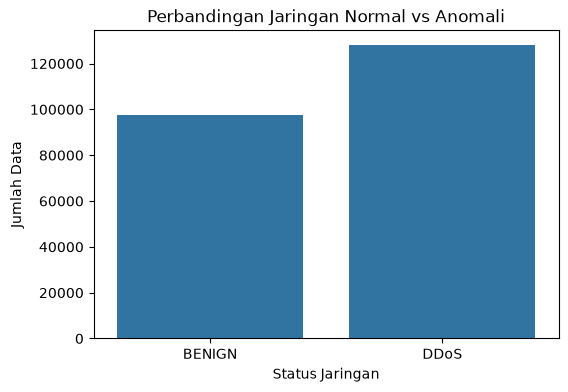

In [3]:
# cek kolom paling akhir di dataset
kolom_target = df.columns[-1]
print("Nama kolom target otomatis terdeteksi:", repr(kolom_target))

# plot otomatis pakai kolom terakhir tersebut
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x=kolom_target, data=df)
plt.title('Perbandingan Jaringan Normal vs Anomali')
plt.xlabel('Status Jaringan')
plt.ylabel('Jumlah Data')
plt.show()


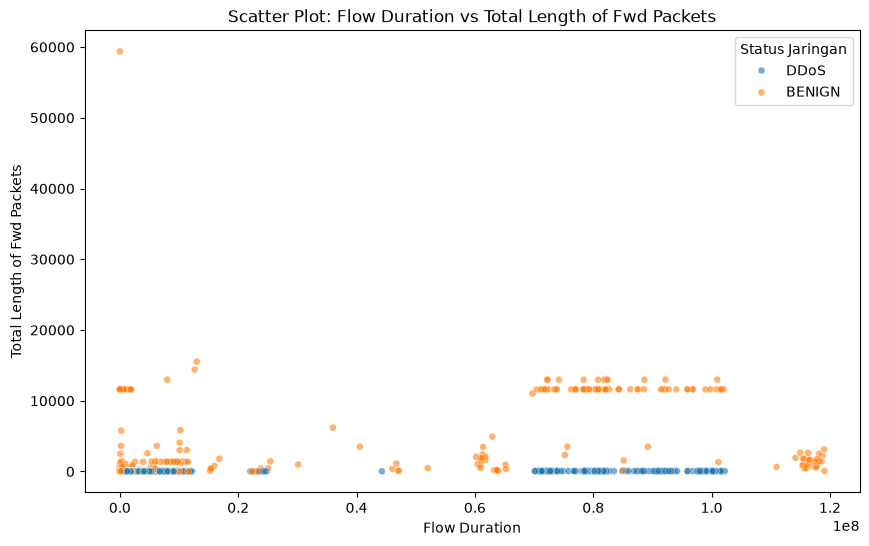

In [4]:
# Cell 4: Scatter Plot - Hubungan Flow Duration & Total Length of Fwd Packets
# Menunjukkan bagaimana durasi aliran (flow) berhubungan dengan total ukuran paket forward.
# Nama kolom asli mengandung spasi di depan (mis. ' Label'), jadi dipetakan dulu ke nama bersih.
kolom = {c.strip(): c for c in df.columns}

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df.sample(n=2000, random_state=42),
    x=kolom['Flow Duration'],
    y=kolom['Total Length of Fwd Packets'],
    hue=kolom['Label'],
    alpha=0.6,
    s=25
)
plt.title('Scatter Plot: Flow Duration vs Total Length of Fwd Packets')
plt.xlabel('Flow Duration')
plt.ylabel('Total Length of Fwd Packets')
plt.legend(title='Status Jaringan', loc='upper right')
plt.show()

Kolom numerik yang dipakai untuk korelasi: 68 dari 78


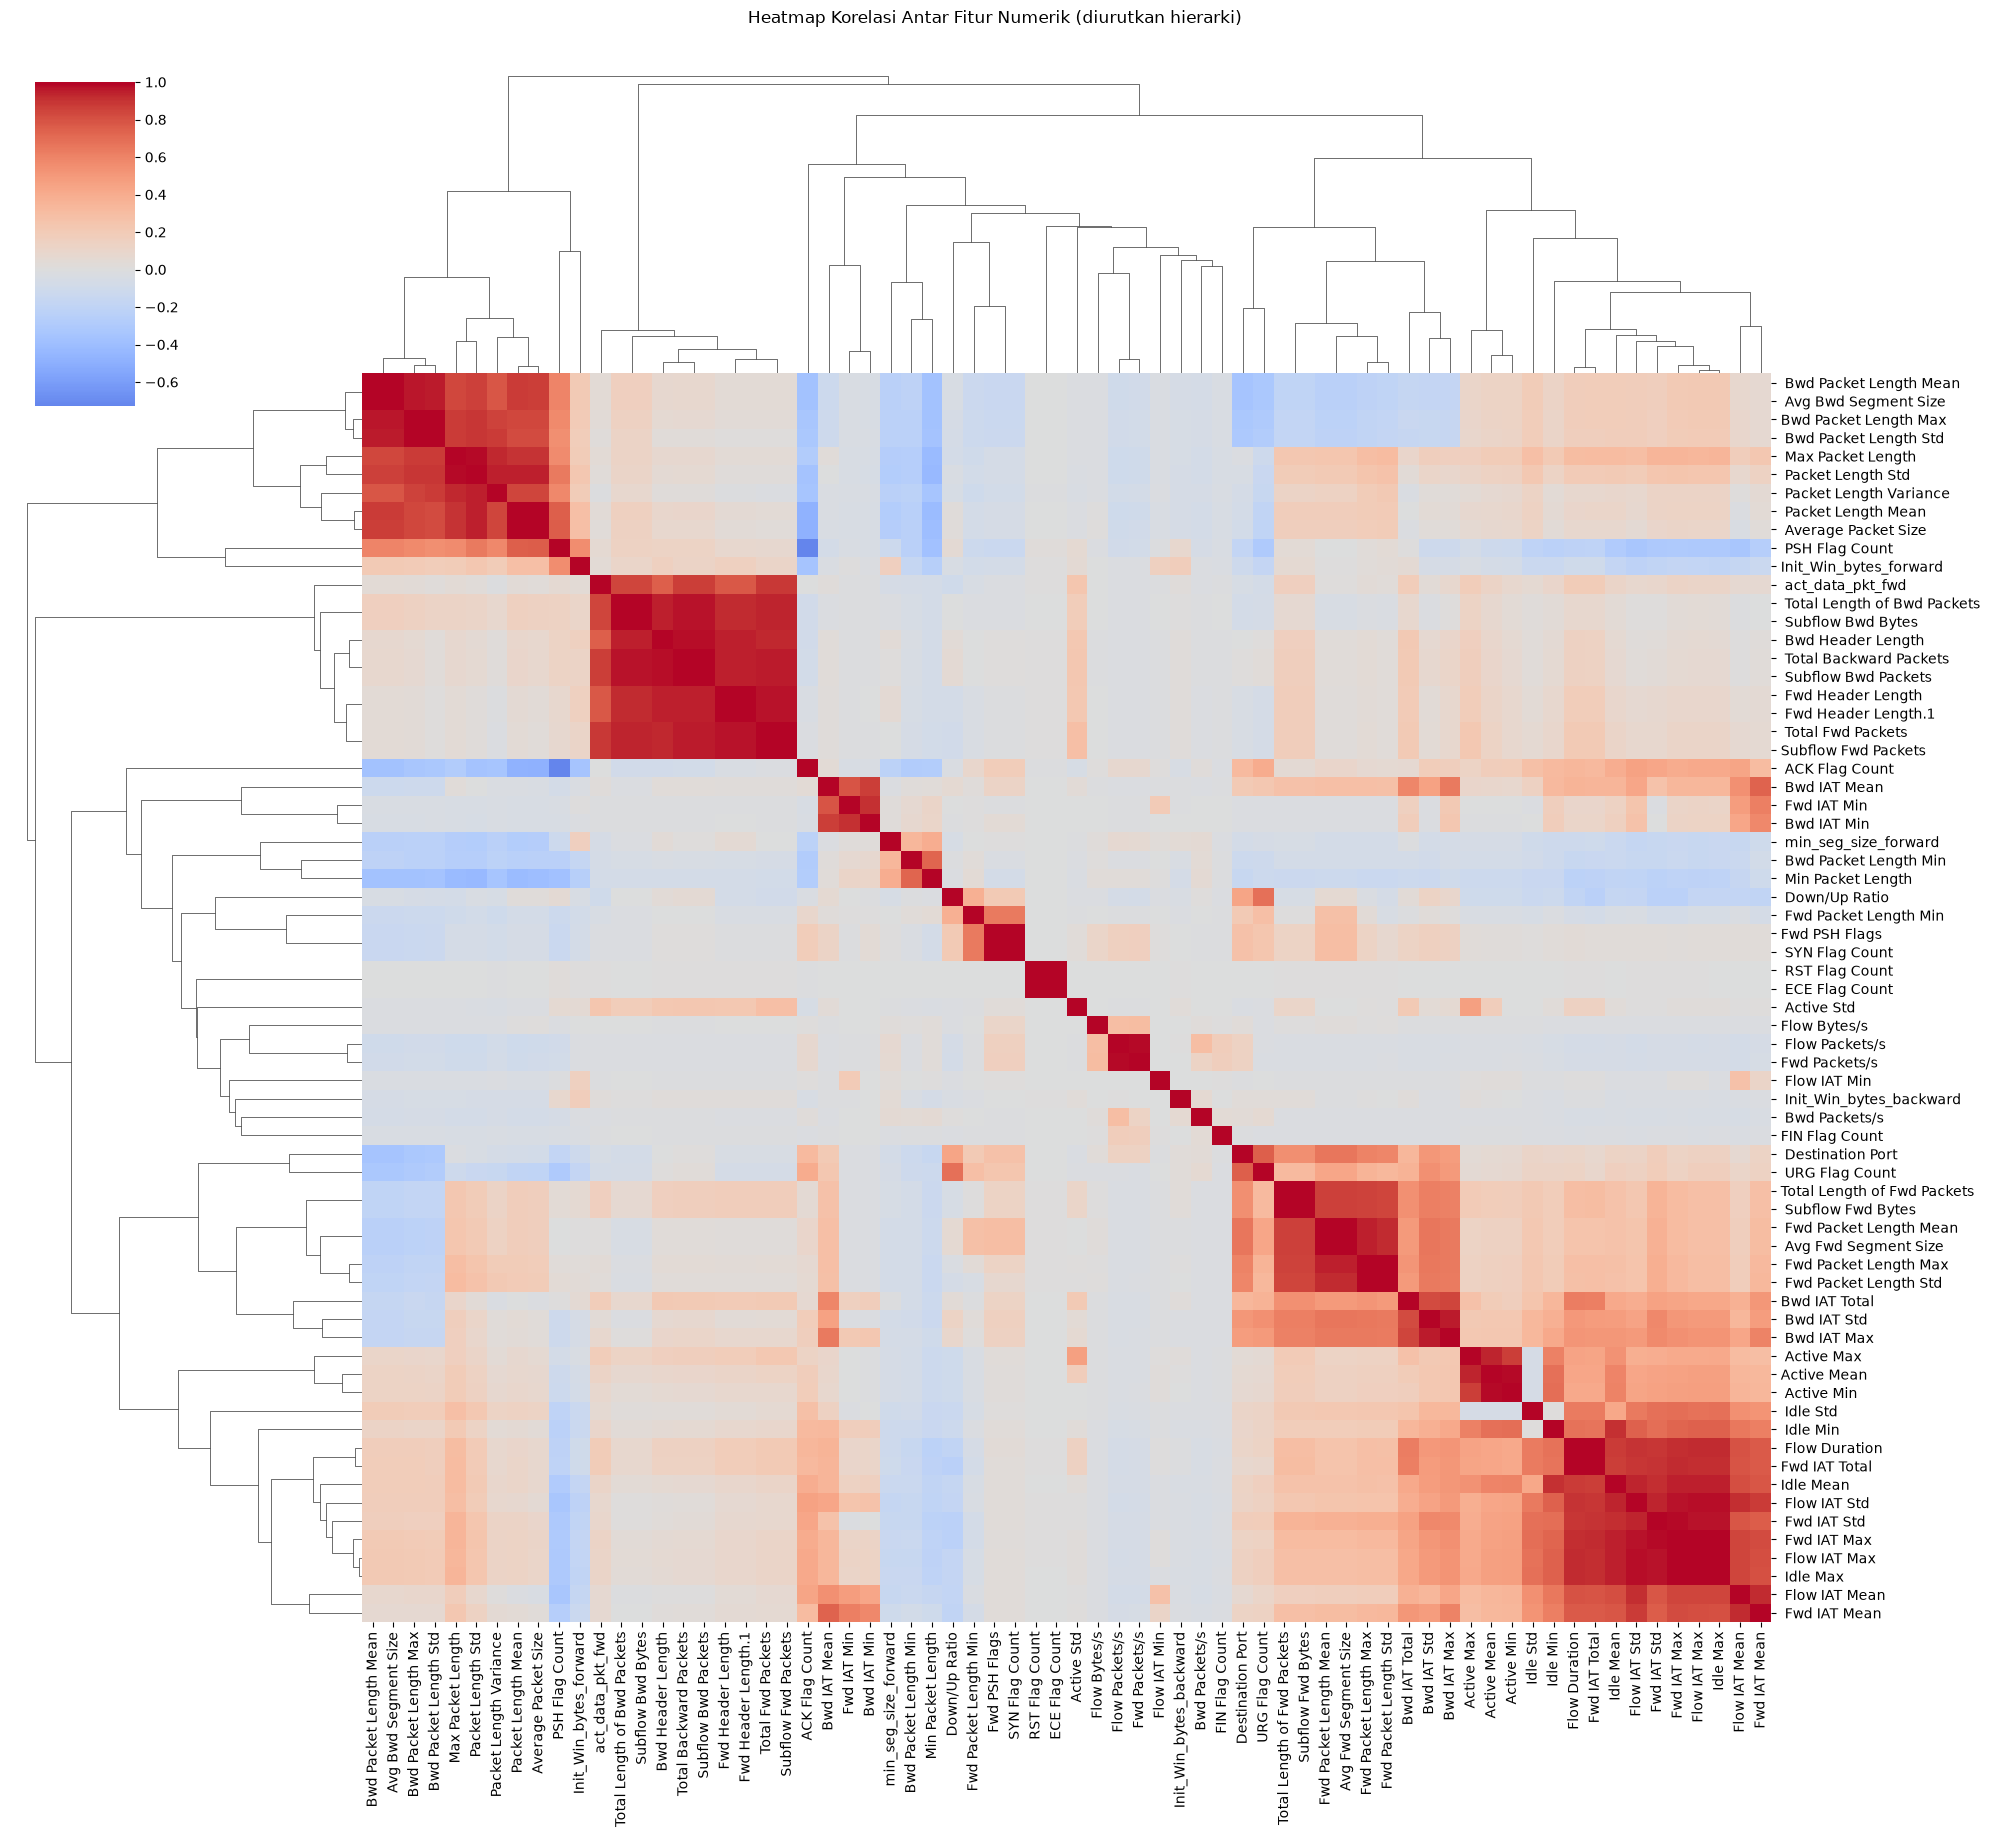

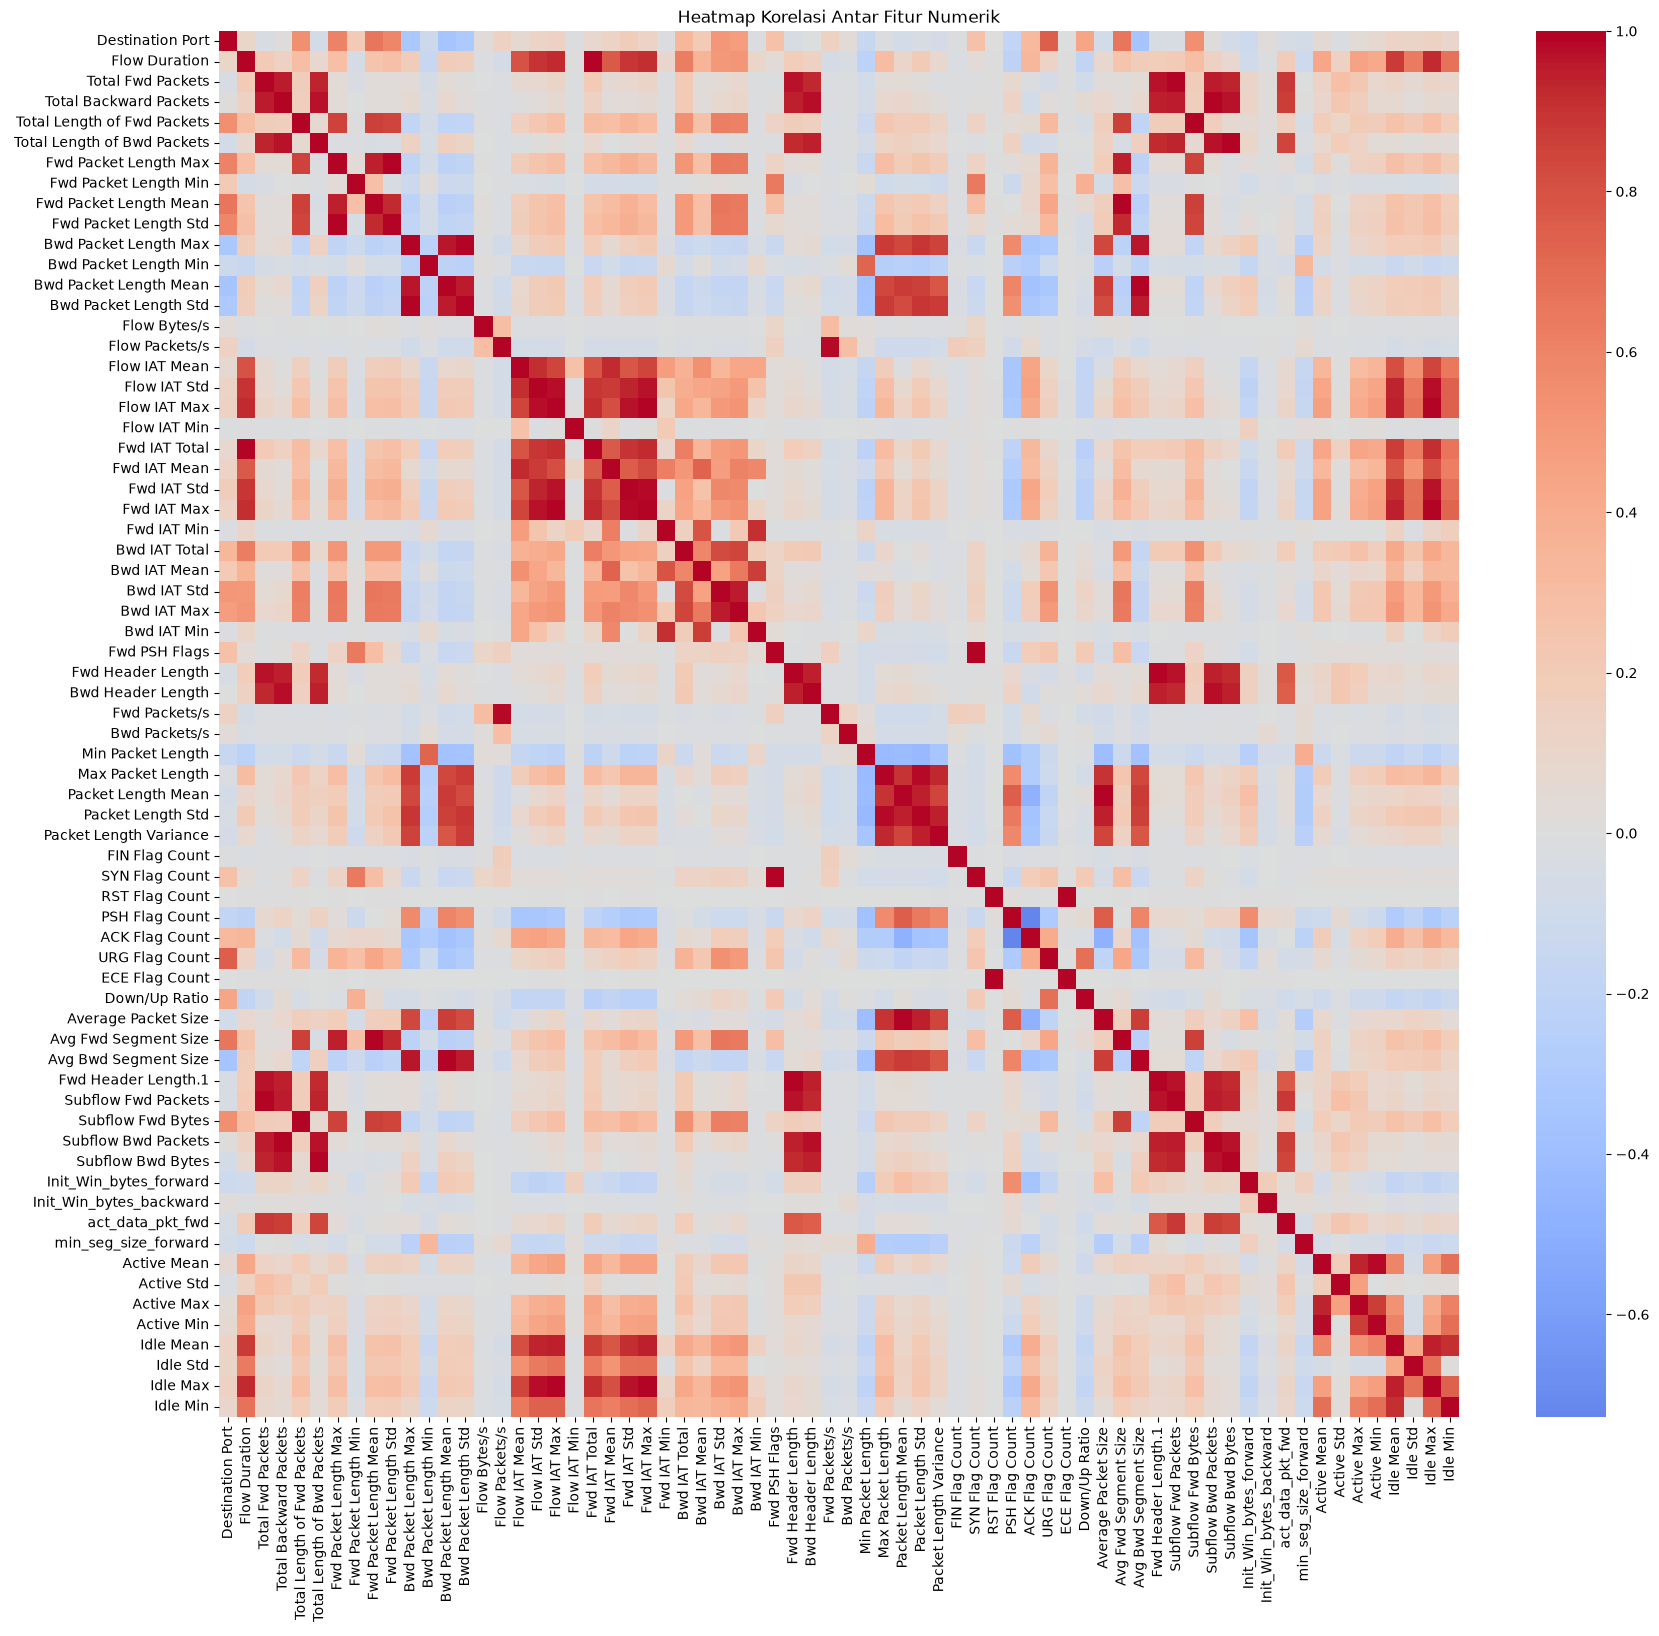

In [6]:
# Cell 6: Heatmap Korelasi Variabel Numerik
# Matriks korelasi antar seluruh fitur numerik.
# Dataset mengandung nilai Inf (fitur rate hasil pembagian) & kolom konstan
# yang membuat korelasi jadi NaN -> dibersihkan dulu sebelum dihitung.
import numpy as np

numeric_df = df.select_dtypes(include=['number'])

# 1) Inf dianggap missing
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

# 2) buang kolom yang tidak punya variasi (konstan)
numeric_df = numeric_df.loc[:, numeric_df.std() > 0]

# 3) isi sisa NaN dengan median tiap kolom agar korelasi bisa dihitung
numeric_df = numeric_df.fillna(numeric_df.median())

corr = numeric_df.corr()
print(f'Kolom numerik yang dipakai untuk korelasi: {corr.shape[0]} dari {df.select_dtypes(include=["number"]).shape[1]}')

# Buang baris/kolom yang masih punya NaN/Inf (antisipasi)
valid = corr.columns[corr.notna().all() & np.isfinite(corr).all()]
corr = corr.loc[valid, valid]

if corr.shape[0] < 2:
    print('Terlalu sedikit kolom valid untuk korelasi, lewati heatmap.')
else:
    # Versi diurutkan hierarki: blok variabel yang saling berkorelasi terlihat jelas
    g = sns.clustermap(
        corr,
        cmap='coolwarm',
        center=0,
        annot=False,
        linewidths=0,
        figsize=(20, 18)
    )
    g.fig.suptitle('Heatmap Korelasi Antar Fitur Numerik (diurutkan hierarki)', y=1.02)
    plt.show()

    # Versi polos urutan kolom asli, untuk perbandingan
    plt.figure(figsize=(20, 18))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0)
    plt.title('Heatmap Korelasi Antar Fitur Numerik')
    plt.show()